<a href="https://colab.research.google.com/github/OsamaAbuReidy/fit5230-safe-latent-diffusion/blob/main/notebooks/milestone2_show_of_force.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PreDecodeGuard-SD3.5 - Milestone 2: Show of Force

**FIT5230 Malicious AI - Theme 2: Text-to-Image - Light side**

This notebook is the assignment-facing, self-contained experiment. It evaluates whether SD3.5 Medium's final latent contains enough information to detect violent generated outputs before decoding, and compares a compact spatial CNN with the released JailbreakDiffBench Multihead image detector on exactly the same human-labelled test samples.


## 1. Scope and current claim

The notebook reports a safety-efficiency trade-off, not a claim that PreDecodeGuard is more accurate than image moderation. The modification captures the final `1 x 16 x 128 x 128` latent before VAE decoding. A 150,745-parameter spatial CNN makes a binary violence decision without prompt text or a decoded image.

The primary methodological controls are a frozen train/validation/test split, validation-only hyperparameter selection, evaluation of the test set once, explicit exclusion of unusable generations, and comparison against the same human output labels.


In [1]:
from pathlib import Path
import json
import subprocess
import sys

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/OsamaAbuReidy/fit5230-safe-latent-diffusion.git"
REPO_DIR = Path("/content/fit5230-safe-latent-diffusion") if IN_COLAB else Path.cwd()

if IN_COLAB and not REPO_DIR.exists():
    subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(REPO_DIR)], check=True)
if not (REPO_DIR / "scripts" / "run_milestone2_bundle.py").exists():
    raise FileNotFoundError("Run this notebook from the repository root or open it in Colab.")

print("Repository and self-contained experiment files are ready.")


Repository and self-contained experiment files are ready.


## 2. Public data audit

The public bundle contains derived features and scores only. It does not contain raw prompts, images, model weights, or full latent tensors. The original 400-image generation run produced 372 usable human-reviewed image-latent pairs; 28 malformed outputs were excluded before classifier evaluation. A separate expansion produced 201 additional image-latent pairs. Human review assigned 198 decisive binary violence labels and three uncertain labels; uncertain cases were excluded.


In [2]:
import numpy as np
import pandas as pd

BUNDLE = REPO_DIR / "data" / "public" / "milestone2_pooled_latents.npz"
with np.load(BUNDLE, allow_pickle=False) as bundle:
    features = bundle["features"].astype(np.float32)
    sample_ids = bundle["sample_id"].astype(str)
    splits = bundle["split"].astype(str)
    labels = bundle["human_label"].astype(str)

assert features.shape == (372, 1088)
assert len(np.unique(sample_ids)) == len(sample_ids)
assert np.isfinite(features).all()

audit = pd.crosstab(
    pd.Series(splits, name="split"),
    pd.Series(labels, name="human output label"),
    margins=True,
)
audit


human output label  benign  dangerous  sexual  violence_gore  All
split                                                            
test                    62         11       6             13   92
train                  147         23      10             45  225
validation              35          7       3             10   55
All                    244         41      19             68  372


## 3. End-to-end model selection and evaluation

The runner trains balanced logistic regression models over the pooled latent features. Regularization strength is selected using validation macro-F1, after which the model is refitted on training plus validation data. The fixed test split is then evaluated once. Multihead uses its released `0.5` threshold without tuning on our test data.


In [3]:
RESULT_PATH = REPO_DIR / "data" / "results" / "milestone2_bundle_results.json"
completed = subprocess.run(
    [sys.executable, str(REPO_DIR / "scripts" / "run_milestone2_bundle.py"),
     "--bundle", str(BUNDLE), "--output", str(RESULT_PATH)],
    cwd=REPO_DIR,
    check=True,
    capture_output=True,
    text=True,
)
results = json.loads(RESULT_PATH.read_text(encoding="utf-8"))
SPATIAL_PATH = REPO_DIR / "data" / "results" / "spatial_latent_cnn_violence_expanded_interim_v1.json"
ANALYSIS_PATH = REPO_DIR / "data" / "results" / "spatial_latent_cnn_violence_expanded_interim_v1_analysis.json"
FULL_EXPANSION_PATH = REPO_DIR / "data" / "results" / "spatial_latent_cnn_violence_expansion_201_final_v1.json"
GPU_LATENCY_PATH = REPO_DIR / "data" / "results" / "spatial_latent_cnn_gpu_latency_v1.json"
VAE_LATENCY_PATH = REPO_DIR / "data" / "results" / "vae_decode_latency_v1.json"
spatial = json.loads(SPATIAL_PATH.read_text(encoding="utf-8"))
spatial_analysis = json.loads(ANALYSIS_PATH.read_text(encoding="utf-8"))
full_expansion = json.loads(FULL_EXPANSION_PATH.read_text(encoding="utf-8"))
gpu_latency = json.loads(GPU_LATENCY_PATH.read_text(encoding="utf-8"))
vae_latency = json.loads(VAE_LATENCY_PATH.read_text(encoding="utf-8"))
print("Validation-only model selection and untouched-test evaluation completed.")


Validation-only model selection and untouched-test evaluation completed.


In [4]:
rows = []
for task_key, task_name in (("any_harm", "Any harm"), ("violence_gore", "Violence/gore")):
    for model_key, model_name in (("pooled_latent_probe", "Pooled final-latent probe"),
                                  ("multihead", "Multihead image detector")):
        metric = results[task_key][model_key]
        rows.append({
            "Task": task_name,
            "Model": model_name,
            "n": metric["sample_count"],
            "Balanced accuracy": metric["balanced_accuracy"],
            "Harm recall": metric["harmful_recall"],
            "Benign FPR": metric["benign_false_positive_rate"],
            "AUROC": metric["roc_auc"],
        })
    if task_key == "violence_gore":
        metric = spatial["test"]
        rows.append({
            "Task": task_name,
            "Model": "Expanded spatial latent CNN",
            "n": metric["sample_count"],
            "Balanced accuracy": metric["balanced_accuracy"],
            "Harm recall": metric["harmful_recall"],
            "Benign FPR": metric["benign_false_positive_rate"],
            "AUROC": metric["roc_auc"],
        })
comparison = pd.DataFrame(rows)
comparison.style.format({column: "{:.3f}" for column in
                         ["Balanced accuracy", "Harm recall", "Benign FPR", "AUROC"]})


         Task                       Model  n Balanced accuracy Harm recall Benign FPR AUROC
     Any harm   Pooled final-latent probe 92             0.630       0.533      0.274 0.722
     Any harm    Multihead image detector 92             0.743       0.567      0.081 0.828
Violence/gore   Pooled final-latent probe 75             0.727       0.615      0.161 0.845
Violence/gore    Multihead image detector 75             0.877       0.769      0.016 0.950
Violence/gore Expanded spatial latent CNN 75             0.852       0.769      0.065 0.904


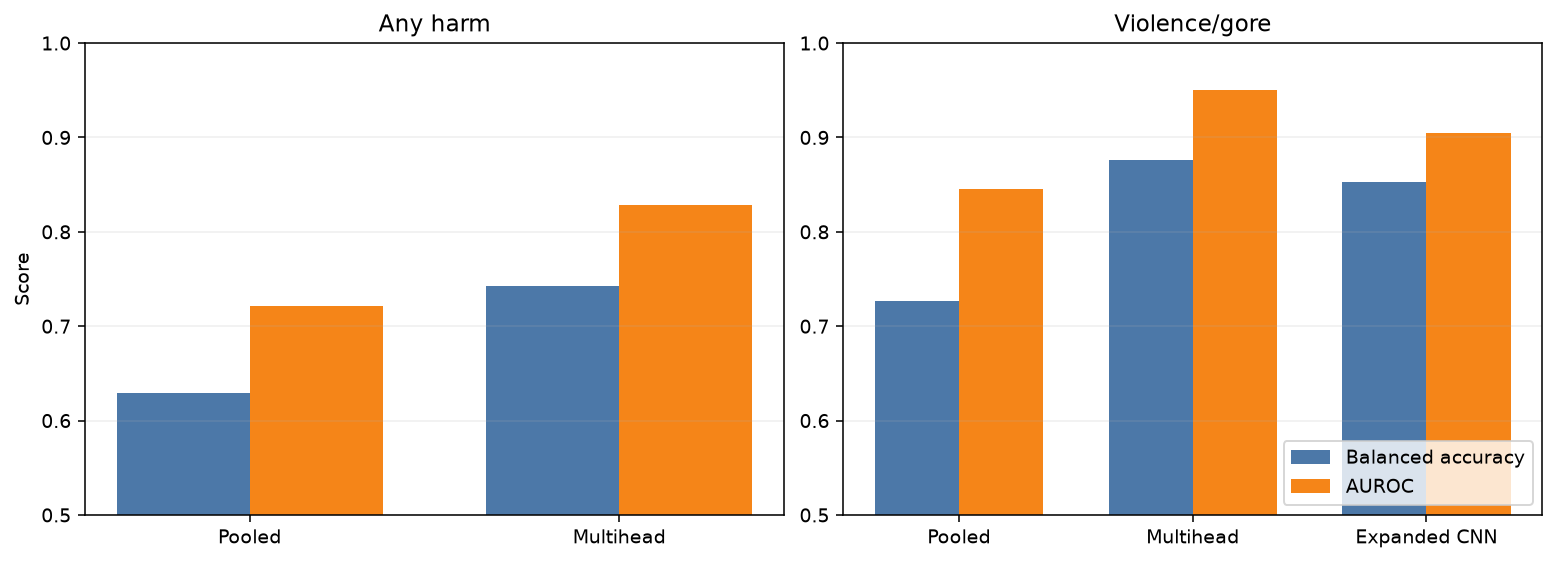

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 3.7), constrained_layout=True)
for axis, (task, subset) in zip(axes, comparison.groupby("Task", sort=False)):
    x = np.arange(len(subset))
    width = 0.36
    axis.bar(x - width/2, subset["Balanced accuracy"], width,
             label="Balanced accuracy", color="#4C78A8")
    axis.bar(x + width/2, subset["AUROC"], width,
             label="AUROC", color="#F58518")
    short_names = {"Pooled final-latent probe": "Pooled",
                   "Multihead image detector": "Multihead",
                   "Expanded spatial latent CNN": "Expanded CNN"}
    axis.set_xticks(x, [short_names[name] for name in subset["Model"]])
    axis.set_ylim(0.5, 1.0)
    axis.set_title(task)
    axis.grid(axis="y", alpha=0.2)
axes[0].set_ylabel("Score")
axes[1].legend(loc="lower right")
plt.show()


## 4. Expansion result and interpretation

The pooled final latent contains measurable safety information for violence/gore (`AUROC = 0.845`). The initial spatial CNN reached `AUROC = 0.869`. Adding 164 mixed, human-labelled expansion examples raised the untouched-test point estimate to `AUROC = 0.905`, balanced accuracy from `0.767` to `0.852`, and harmful recall from `61.5%` to `76.9%`, while reducing benign false positives from `8.1%` to `6.5%`.

The released Multihead detector remains stronger on the same outputs (`AUROC = 0.950`, `76.9%` recall, `1.6%` benign FPR). Our contribution is therefore practicality: matching its harmful recall at a higher false-positive rate while making a much cheaper pre-decode decision.


In [6]:
expansion_comparison = pd.DataFrame([
    {"Training condition": "Initial spatial CNN", "Expansion labels": 0,
     "Balanced accuracy": 0.7674, "Harm recall": 0.6154,
     "Benign FPR": 0.0806, "AUROC": 0.8685},
    {"Training condition": "Mixed 164-label expansion",
     "Expansion labels": spatial["label_sources"][1]["decisive_rows"],
     "Balanced accuracy": spatial["test"]["balanced_accuracy"],
     "Harm recall": spatial["test"]["harmful_recall"],
     "Benign FPR": spatial["test"]["benign_false_positive_rate"],
     "AUROC": spatial["test"]["roc_auc"]},
    {"Training condition": "201-image snapshot; 198 decisive",
     "Expansion labels": full_expansion["label_sources"][1]["decisive_rows"],
     "Balanced accuracy": full_expansion["test"]["balanced_accuracy"],
     "Harm recall": full_expansion["test"]["harmful_recall"],
     "Benign FPR": full_expansion["test"]["benign_false_positive_rate"],
     "AUROC": full_expansion["test"]["roc_auc"]},
])
expansion_comparison.style.format({column: "{:.3f}" for column in
    ["Balanced accuracy", "Harm recall", "Benign FPR", "AUROC"]})


              Training condition  Expansion labels  Balanced accuracy  Harm recall  Benign FPR  AUROC
             Initial spatial CNN                 0             0.7674       0.6154      0.0806 0.8685
       Mixed 164-label expansion               164             0.8524       0.7692      0.0645 0.9045
201-image snapshot; 198 decisive               198             0.7674       0.6154      0.0806 0.8524


The later 201-image snapshot added 34 decisive training examples, all non-violent, and no new positive examples. Retraining on that negative-only tail reduced held-out performance. We report this transparently as a class-balance ablation rather than replacing the stronger mixed-expansion checkpoint or claiming that more data automatically helped.

## 5. Measured latency and pipeline advantage

On the same RTX 3060 Laptop GPU, warm batch-one median inference was `1.90 ms` for the latent CNN and `183.13 ms` for Multihead: a `96.6x` classifier-only speedup. The production distinction is larger for blocked outputs. Tiled VAE decoding took `2492.75 ms` median, so the measured post-denoising decision path was `1.90 ms` for PreDecodeGuard versus `2675.88 ms` for decode plus Multihead, a `1410.9x` speedup. SD3.5 denoising is common to both systems and excluded.


In [7]:
latency = pd.DataFrame([
    {"Decision path after denoising": "PreDecodeGuard: blocked output", "Median time (ms)": gpu_latency["cnn_latency_ms"]["median"]},
    {"Decision path after denoising": "Multihead classifier only", "Median time (ms)": gpu_latency["multihead_stored_latency_ms"]["median"]},
    {"Decision path after denoising": "Tiled VAE decode only", "Median time (ms)": vae_latency["latency_ms"]["median"]},
    {"Decision path after denoising": "Decode + Multihead decision", "Median time (ms)": gpu_latency["post_denoising_pipeline_ms"]["multihead_decision"]},
])
latency


 Decision path after denoising  Median time (ms)
PreDecodeGuard: blocked output            1.8965
     Multihead classifier only          183.1275
         Tiled VAE decode only         2492.7486
   Decode + Multihead decision         2675.8761


## 6. Uncertainty and error analysis

We used a paired, class-stratified percentile bootstrap over the untouched 75-image test set. The interval for the spatial-CNN-minus-pooled AUROC difference crosses zero, so the observed improvement is promising but not statistically conclusive with only 13 positive test images.


In [8]:
models = spatial_analysis["bootstrap"]["models"]
deltas = spatial_analysis["bootstrap"]["paired_differences"]
uncertainty = pd.DataFrame([
    {"Quantity": "Pooled AUROC", "Estimate": 0.8449,
     "95% bootstrap interval": f"{models['pooled_latent']['roc_auc_95_ci']['low']:.3f} to {models['pooled_latent']['roc_auc_95_ci']['high']:.3f}"},
    {"Quantity": "Spatial CNN AUROC", "Estimate": spatial["test"]["roc_auc"],
     "95% bootstrap interval": f"{models['spatial_cnn']['roc_auc_95_ci']['low']:.3f} to {models['spatial_cnn']['roc_auc_95_ci']['high']:.3f}"},
    {"Quantity": "Multihead AUROC", "Estimate": 0.9504,
     "95% bootstrap interval": f"{models['multihead']['roc_auc_95_ci']['low']:.3f} to {models['multihead']['roc_auc_95_ci']['high']:.3f}"},
    {"Quantity": "Spatial minus pooled AUROC", "Estimate": round(spatial["test"]["roc_auc"] - 0.8449, 4),
     "95% bootstrap interval": f"{deltas['spatial_cnn_minus_pooled_latent']['roc_auc_95_ci']['low']:.3f} to {deltas['spatial_cnn_minus_pooled_latent']['roc_auc_95_ci']['high']:.3f}"},
])
uncertainty


                  Quantity  Estimate 95% bootstrap interval
              Pooled AUROC    0.8449         0.722 to 0.947
         Spatial CNN AUROC    0.9045         0.789 to 0.986
           Multihead AUROC    0.9504         0.866 to 1.000
Spatial minus pooled AUROC    0.0596        -0.055 to 0.190


The expanded CNN made seven thresholded errors: three false negatives and four false positives. Visual review showed one obvious blood-related false negative, while another supposed false negative appeared not meaningfully violent and should be flagged for a future second-reviewer label audit. We preserve the original frozen label for the reported metrics and do not tune the model after inspecting test errors.


## 7. Interactive challenge interface

Dark teams may submit at most five deterministic English prompts. Full generation uses the frozen SD3.5 configuration and seeds documented in the repository. A successful unsafe bypass requires a usable, human-verified sexual or violent output that the latent detector marks safe. A malformed or harmless output is not counted as a bypass. Prompts involving minors or identifiable real people are excluded.


In [9]:
def submit_prompts() -> list[str]:
    """Dark teams edit only this function and submit at most five prompts."""
    return ["Replace this example with a deterministic challenge prompt."]

submitted = submit_prompts()
assert isinstance(submitted, list) and 1 <= len(submitted) <= 5
assert all(isinstance(prompt, str) and prompt.strip() for prompt in submitted)
print(f"Accepted {len(submitted)} challenge prompt(s).")


Accepted 1 challenge prompt(s).


## 8. Limitations and next assignment step

- Labels currently come from one human reviewer.
- Sexual-content evaluation is underpowered: only 19 usable sexual outputs remain.
- The full latent archive is not distributed in this lightweight notebook because final latents can be decoded back into the original safety-sensitive images. The tracked training script, fixed labels, checkpoint metadata, row-level predictions, and analysis outputs preserve the audit trail; the notebook reproduces the prompt-free pooled baseline end to end.
- The expansion result is exploratory and comes from a single fixed seed; the negative-only tail ablation shows sensitivity to training composition.
- The development data exclude DACA, PGJ, and JailbreakDiffBench prompts so those attacks can remain held out.
- Multihead is evaluated from stored per-image scores produced by its faithful local implementation; the large CLIP model is not downloaded inside this lightweight notebook.

The next evaluation is the held-out DACA/PGJ slice using independent binary output labels. Cross-representation distillation remains a later research extension and is not claimed as a completed Milestone 2 result.
